In [1]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import  HDBSCAN
import matplotlib.pyplot as plt

print("loaded")

c:\Users\amirh\Documents\projects\youtube-intelligence-engine\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded


In [2]:
df = pd.read_csv("../data/processed/comments_sentiment.csv")

#using lemmatized text for topic modeling
docs = df["text_lemma"].dropna().tolist()

print("Documents loaded:", len(docs))
print("sample:", docs[0])

Documents loaded: 27269
sample: wow blow mind commenter think video software program draw hand actual whiteboard dry erase marker probably use smell marker good love draw peaceful fun help learn lot irony push human real world hobby play instrument climb tree wood carving weld sport read physical book etc slop appreciate real world


In [6]:
# embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")

# reduce embedding dimensions before clustering
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# cluster the reduced embeddings
hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric="euclidean",
    prediction_data=True
)

#build BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)
print("\nDone")
print("Number of topics found:", len(set(topics)) - 1)
# -1 excluded outlier topic

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5066.71it/s]
2026-06-11 15:31:23,393 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 853/853 [00:17<00:00, 49.76it/s]
2026-06-11 15:31:40,686 - BERTopic - Embedding - Completed ✓
2026-06-11 15:31:40,686 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-11 15:32:08,665 - BERTopic - Dimensionality - Completed ✓
2026-06-11 15:32:08,668 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-11 15:32:13,686 - BERTopic - Cluster - Completed ✓
2026-06-11 15:32:13,702 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-11 15:32:14,244 - BERTopic - Representation - Completed ✓



Done
Number of topics found: 79


In [7]:
# get top 15 topics by size
topic_info = topic_model.get_topic_info()
print(topic_info[["Topic", "Count", "Name"]].head(16))  # 16 because topic -1 is outliers

    Topic  Count                                    Name
0      -1  14303                -1_human_people_job_work
1       0   1425           0_code_developer_cod_software
2       1    657                 1_robot_robotic_job_buy
3       2    499  2_capitalism_communism_marx_capitalist
4       3    408         3_company_profit_investor_stock
5       4    363             4_art_artist_beautiful_draw
6       5    362     5_ceo_shareholder_replace_executive
7       6    277                 6_bubble_burst_pop_wait
8       7    273          7_people_rich_money_government
9       8    248                8_llm_language_model_agi
10      9    242           9_rich_billionaire_money_poor
11     10    240             10_tech_hype_technology_bro
12     11    234              11_video_min_watch_footage
13     12    226            12_ubi_study_money_inflation
14     13    226            13_replace_job_hire_employee
15     14    224          14_climate_energy_water_center


In [8]:
# print top keywords for first 10 topics
for topic_id in range(10):
    words = topic_model.get_topic(topic_id)
    keywords = [w[0] for w in words[:8]]
    print(f"Topic {topic_id}: {', '.join(keywords)}")

Topic 0: code, developer, cod, software, write, engineer, vibe, junior
Topic 1: robot, robotic, job, buy, need, money, people, work
Topic 2: capitalism, communism, marx, capitalist, socialism, communist, worker, karl
Topic 3: company, profit, investor, stock, invest, corporation, market, sell
Topic 4: art, artist, beautiful, draw, create, music, love, image
Topic 5: ceo, shareholder, replace, executive, decision, company, board, employee
Topic 6: bubble, burst, pop, wait, crash, hype, go, definitely
Topic 7: people, rich, money, government, need, live, work, country
Topic 8: llm, language, model, agi, intelligence, translation, text, generative
Topic 9: rich, billionaire, money, poor, eat, buy, wealth, people


In [9]:
# add topics to df and handle the length difference from dropna earlier
df_topics = df.dropna(subset=["text_lemma"]).copy()
df_topics["topic"] = topics
df_topics["topic_name"] = df_topics["topic"].apply(
    lambda t: topic_model.get_topic_info().set_index("Topic").loc[t, "Name"] if t != -1 else "outlier"
)

print("Topic distribution:")
print(df_topics["topic"].value_counts().head(10))

df_topics.to_csv("../data/processed/comments_topics.csv", index=False, encoding="utf-8-sig")
print(f"\nSaved {len(df_topics)} rows")

Topic distribution:
topic
-1    14303
 0     1425
 1      657
 2      499
 3      408
 4      363
 5      362
 6      277
 7      273
 8      248
Name: count, dtype: int64

Saved 27269 rows


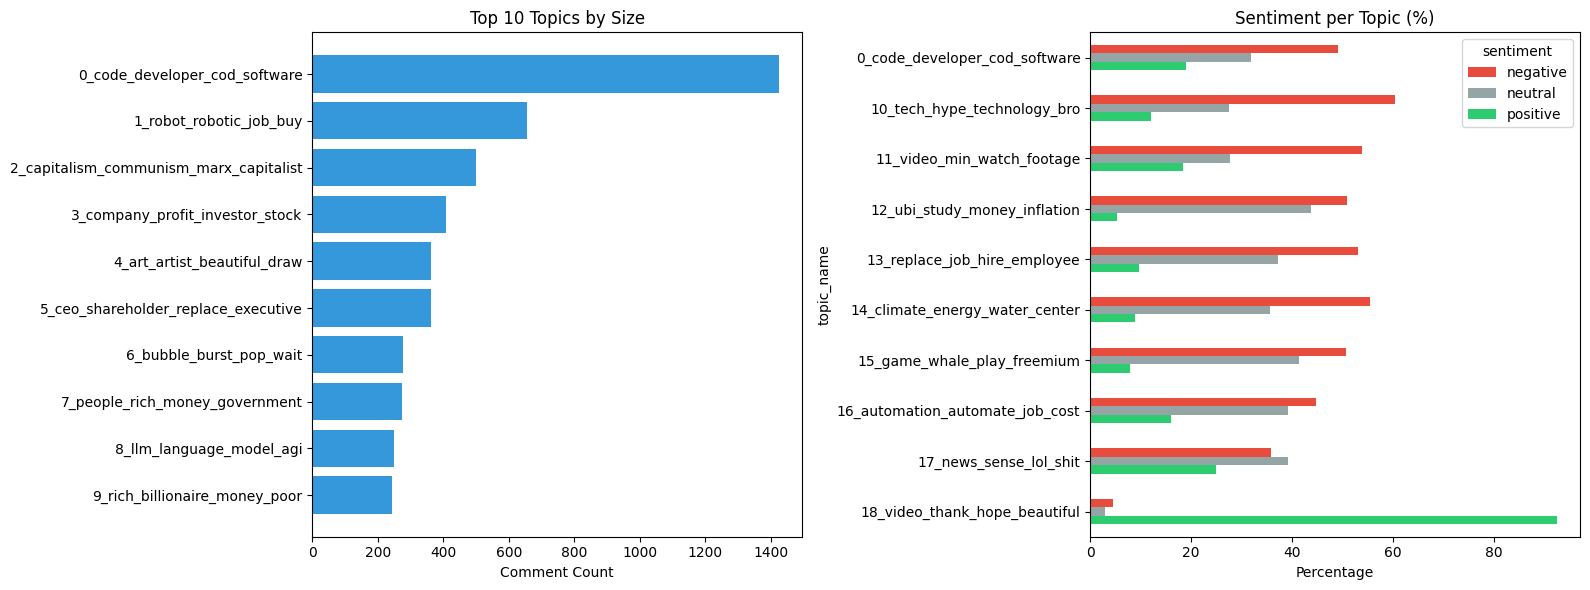

Chart saved.


In [10]:
# merge sentiment into df_topics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# topic sizes - exclude outliers
topic_counts = df_topics[df_topics["topic"] != -1]["topic_name"].value_counts().head(10)
axes[0].barh(topic_counts.index, topic_counts.values, color="#3498db")
axes[0].set_title("Top 10 Topics by Size")
axes[0].set_xlabel("Comment Count")
axes[0].invert_yaxis()

# sentiment per topic - exclude outliers
topic_sentiment = df_topics[df_topics["topic"] != -1].groupby(
    ["topic_name", "sentiment"]).size().unstack(fill_value=0)
topic_sentiment_pct = topic_sentiment.div(topic_sentiment.sum(axis=1), axis=0) * 100
topic_sentiment_pct[["negative", "neutral", "positive"]].head(10).plot(
    kind="barh", ax=axes[1], color=["#e74c3c", "#95a5a6", "#2ecc71"]
)
axes[1].set_title("Sentiment per Topic (%)")
axes[1].set_xlabel("Percentage")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../data/processed/topic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")